In [1]:
#Importing necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Loading dataset
df = pd.read_csv("Bank_Personal_Loan_Modelling(1)[1].csv")

#Dropping unnecessary columns
df = df.drop(['ID', 'ZIP Code', 'Securities Account','Family'], axis=1)
#Addng 'Marital Status' as a new synthetic feature (Requirement)
df['Marital Status'] = np.random.randint(1,3,size=len(df))

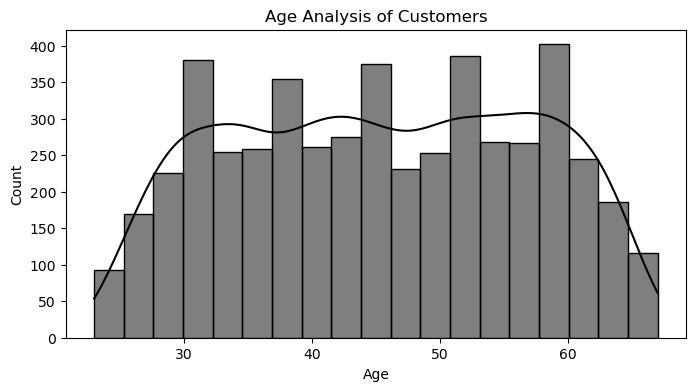

In [2]:
#Visualizing the age distribution of customers using a histogram
plt.figure(figsize=(8,4))
sns.histplot(df['Age'],kde=True, color='black')
plt.title('Age Analysis of Customers')
plt.show()             

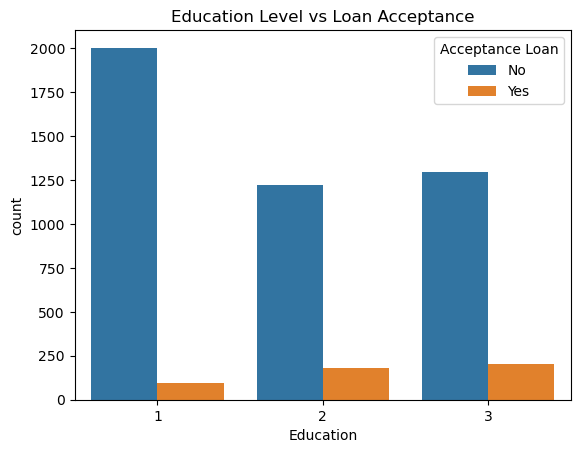

In [3]:
#Education as a proxy for Job (Requirment adjustment)
#1: Undergraduate, 2: Graduate, 3:Professional
sns.countplot(x='Education',hue='Personal Loan', data=df)
plt.title('Education Level vs Loan Acceptance')
plt.legend(title= 'Acceptance Loan', labels= ['No','Yes'])
plt.show()             

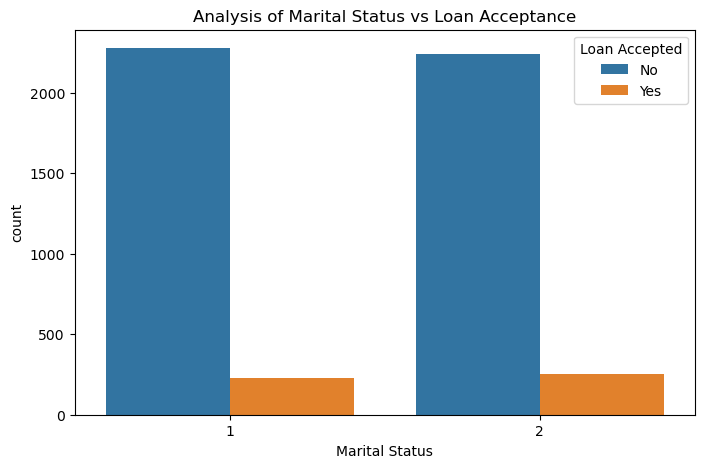

In [4]:
#Marital Status
plt.figure(figsize=(8,5))
sns.countplot(x='Marital Status',hue='Personal Loan', data=df)
plt.title('Analysis of Marital Status vs Loan Acceptance')
plt.legend(title= 'Loan Accepted', labels= ['No','Yes'])
plt.show()             

In [7]:
# Splitting data into Training (80%) and Testing (20%) sets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


X = df[['Age', 'Education', 'Marital Status']]
y = df['Personal Loan']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#(Logistic Regression machine)
model = LogisticRegression()

#(Training)
model.fit(X_train, y_train)

#(Prediction)
predictions = model.predict(X_test)

#Result
accuracy = accuracy_score(y_test, predictions)
print(f"Machine Learning Accuracy: {accuracy * 100:.2f}%")

Machine Learning Accuracy: 89.50%


In [8]:
#(Feature Importance)
importance = model.coef_[0]
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
print(feature_importance_df.sort_values(by='Importance', ascending=False))

          Feature  Importance
1       Education    0.522687
2  Marital Status    0.185307
0             Age   -0.001974
